```
<11_vehicle.ipynb>

제미나이 의존도: 60-70%

오늘은 자동차를 주제로 객체탐지 학습을 해보았다.
이번에도 csv 파일인데, 전에 했던 human face와 달리 좀 불친절했다랄까?
컬럼 이름이 따로 없었고, 내가 추측해야 했다.
근데 딱 봐도 image_id, class_name, xmin, ymin, xmax, ymax였다.

역시.. 여러가지 데이터셋을 다뤄봐야 한다.. 이것도 다 경험이 될거라 생각한다.

다음에도 csv파일이 있는 객체 탐지 데이터셋을 다뤄볼까
```

In [63]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import cv2
from PIL import Image # 메타데이터만 빠르게 탐색
import random
import shutil
import time
from ultralytics import YOLO
%matplotlib inline

```
생각해보니까..
csv에 있는 image_id로 각 이미지에 맞는 라벨 파일(txt)을 만들었어도, 
예를 들어 0000324.jpg 라는 이미지도 있는데, 탐지된 물체가 없어서 csv에서 조회도 안된 채로 있을 수도 있다.
```

In [44]:
csv_path = "dataset/vehicle/Object_Detection/labels.csv"
image_path = "dataset/vehicle/Object_Detection/Images"
image_set = set(os.listdir(image_path))
# print(len(image_set)) # 5626

# 컬럼 이름 직접 정의하기
headers = ['image_id', 'class_name', 'xmin', 'ymin', 'xmax', 'ymax']

df = pd.read_csv(csv_path, header=None, names=headers, dtype={'image_id': str})

unique_classes = sorted(df['class_name'].unique())
class_map = {name: idx for idx, name in enumerate(unique_classes)}

labels_path = "dataset/vehicle/Object_Detection/labels"
os.makedirs(labels_path, exist_ok=True)

start_time = time.time()

for image, group in df.groupby('image_id'):
    image_name = f"{image}.jpg"
    if image_name in image_set: # 이미지 경로에 이미지가 진짜로 있다면.
        full_image_path = os.path.join(image_path, image_name)

        # 기존 코드
        # img_bgr = cv2.imread(full_image_path)

        # 우리는 높이, 너비만 필요하기 때문에 RGB 변환 과정은 굳이 안해도 된다!
        # img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        # img_height, img_width, _ = img_rgb.shape

        # 개선 코드
        with Image.open(full_image_path) as img:
            img_width, img_height = img.size

        txt_lines = []

        for idx, row in group.iterrows():
            class_name = row['class_name']
            xmin = row['xmin']
            ymin = row['ymin']
            xmax = row['xmax']
            ymax = row['ymax']

            class_id = class_map[class_name]
            x_center = (xmin + xmax) / (2 * img_width)
            y_center = (ymin + ymax) / (2 * img_height)
            obj_width = (xmax - xmin) / img_width
            obj_height = (ymax - ymin) / img_height

            line = f"{class_id} {x_center:.6f} {y_center:.6f} {obj_width:.6f} {obj_height:.6f}"
            txt_lines.append(line)

        txt_save_path = os.path.join(labels_path, f"{image}.txt")
        with open(txt_save_path, "w", encoding="utf-8") as f:
            if len(txt_lines) > 0:
                f.write('\n'.join(txt_lines) + '\n')
            else:
                print(f"배경 이미지 발견: {image}")
                # f.write('') # 생략해도 0 bytes 파일 생성됨
                
end_time = time.time()
elapsed_time = int(end_time - start_time)
mins, secs = divmod(elapsed_time, 60)
print(f"{mins}:{secs}")

0:2


In [45]:
src_image_list = [f for f in os.listdir(image_path) if f.endswith(('.jpg', '.jpeg', '.png', '.webp'))]
print(len(src_image_list))
random.seed(42)
random.shuffle(src_image_list)

split_idx = int(len(src_image_list) * 0.8)

train_images = src_image_list[:split_idx]
val_images = src_image_list[split_idx:]

set_src_label = set(os.listdir(labels_path))


split_data = {"train": train_images, "valid": val_images}

start_time = time.time()

for split_type, images in split_data.items():
    dest_image_path = f"dataset/vehicle/{split_type}/images"
    dest_label_path = f"dataset/vehicle/{split_type}/labels"

    os.makedirs(dest_image_path, exist_ok=True)
    os.makedirs(dest_label_path, exist_ok=True)
    
    for image in images:
        pure_name, ext = os.path.splitext(image)
        txt_name = f"{pure_name}.txt"
    
        if txt_name in set_src_label:
            full_src_image_path = os.path.join(image_path, image)
            full_dest_image_path = os.path.join(dest_image_path, image)
            shutil.copy(full_src_image_path, full_dest_image_path)
    
            full_src_label_path = os.path.join(labels_path, txt_name)
            full_dest_label_path = os.path.join(dest_label_path, txt_name)
            shutil.copy(full_src_label_path, full_dest_label_path)

elapsed_time = int(time.time() - start_time)
mins, secs = divmod(elapsed_time, 60)
print(f"{mins}:{secs}")

5626
0:2


In [51]:
# print("', '".join(class_map.keys()))

print(list(class_map.keys()))

['articulated_truck', 'bicycle', 'bus', 'car', 'motorcycle', 'motorized_vehicle', 'non-motorized_vehicle', 'pedestrian', 'pickup_truck', 'single_unit_truck', 'work_van']


In [52]:
yaml_save_path = "dataset/vehicle/data.yaml"
with open(yaml_save_path, 'w', encoding='utf-8') as f:
    f.write('train: ../train/images\n')
    f.write('val: ../valid/images\n')
    f.write('\n')
    f.write(f'nc: {len(class_map)}\n')
    f.write(f"names: {list(class_map.keys())}")

In [55]:
model = YOLO('yolov8n.pt')

current_dir = os.getcwd()

start_time = time.time()

model.train(
    data='dataset/vehicle/data.yaml', 
    epochs=10, 
    imgsz=640, 
    device='mps', 
    project=os.path.join(current_dir, 'runs'), 
    name='vehicle'
)

elapsed_time = int(time.time() - start_time)
mins, secs = divmod(elapsed_time, 60)
print(f"{mins}:{secs}")

New https://pypi.org/project/ultralytics/8.4.104 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/vehicle/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle, nbs=64, nm

In [61]:
def inspect_detection(image_path, conf_threshold=0.45, iou_threshold=0.25):
    model = YOLO('runs/vehicle/weights/best.pt')
    preds = model.predict(
        source=image_path, 
        conf=conf_threshold, 
        iou=iou_threshold, 
        device='mps'
    )

    annotated_img = preds[0].plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 10))
    plt.imshow(annotated_img_rgb)
    plt.title(f'Conf: {conf_threshold} | IoU: {iou_threshold}', fontsize=12)
    plt.axis('off')
    plt.show()


image 1/1 /Users/jeongjaehun/Github/03_object_detection/dataset/1-7-scaled.jpg: 384x640 6 cars, 1 single_unit_truck, 805.8ms
Speed: 9.3ms preprocess, 805.8ms inference, 46.6ms postprocess per image at shape (1, 3, 384, 640)


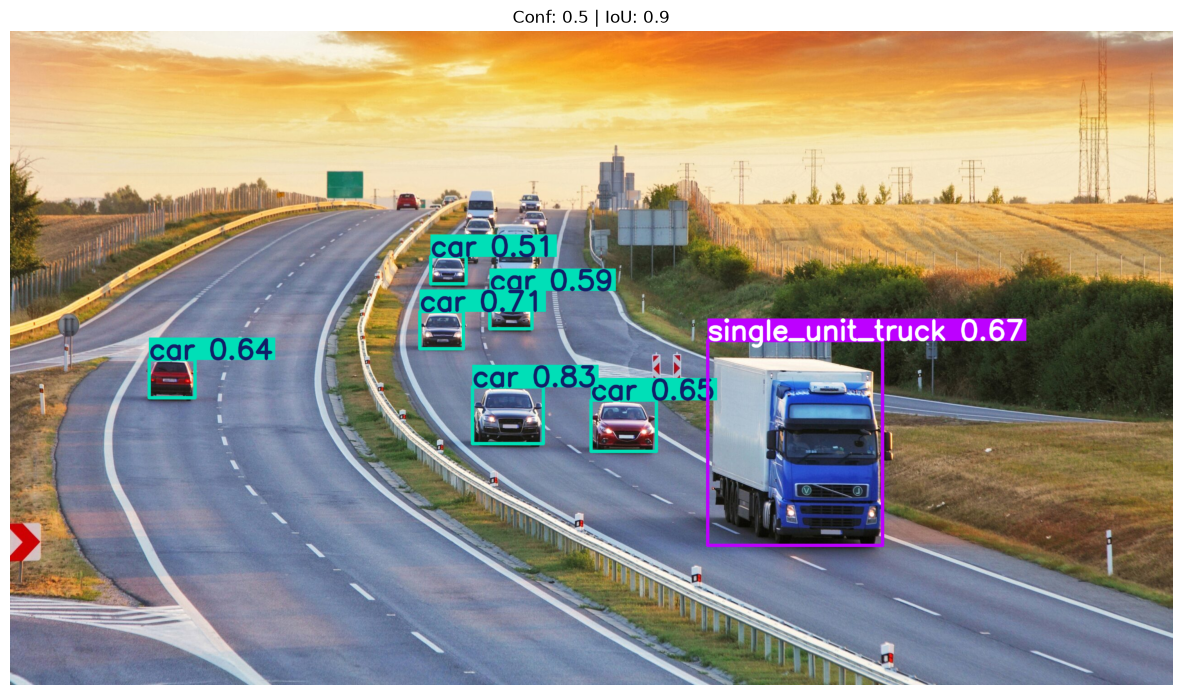

In [65]:
image_path = 'dataset/1-7-scaled.jpg'
inspect_detection(image_path, conf_threshold=0.5, iou_threshold=0.9)